In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
financing_schemes = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-04-21/financing_schemes.csv')
health_spending = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-04-21/health_spending.csv')
spending_purpose = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-04-21/spending_purpose.csv')


In [3]:
financing_schemes.tail(2)

,country_name,iso3_code,year,indicator_code,financing_scheme,value,unit
33238,"occupied Palestinian territory, including east...",PSE,2023,hfnec_che,Unspecified financing schemes (n.e.c.),0.0,% of current health expenditure
33239,"occupied Palestinian territory, including east...",PSE,2023,hfnec_usd2023,Unspecified financing schemes (n.e.c.),0.0,constant 2023 US$


In [4]:
health_spending.tail(2)

,country_name,iso3_code,year,indicator_code,expenditure_type,value,unit
30896,"occupied Palestinian territory, including east...",PSE,2023,pvtd_che,Domestic Private Health Expenditure (PVT-D),4.991536e+01,% of current health expenditure
30897,"occupied Palestinian territory, including east...",PSE,2023,pvtd_usd2023,Domestic Private Health Expenditure (PVT-D),9.333428e+08,constant 2023 US$


In [5]:
spending_purpose.tail(2)

,country_name,iso3_code,year,indicator_code,spending_purpose,value,unit
11734,"occupied Palestinian territory, including east...",PSE,2023,hc9_che,Other health care services not elsewhere class...,0.02092,% of current health expenditure
11735,"occupied Palestinian territory, including east...",PSE,2023,hc9_usd2023,Other health care services not elsewhere class...,391176.86000,constant 2023 US$


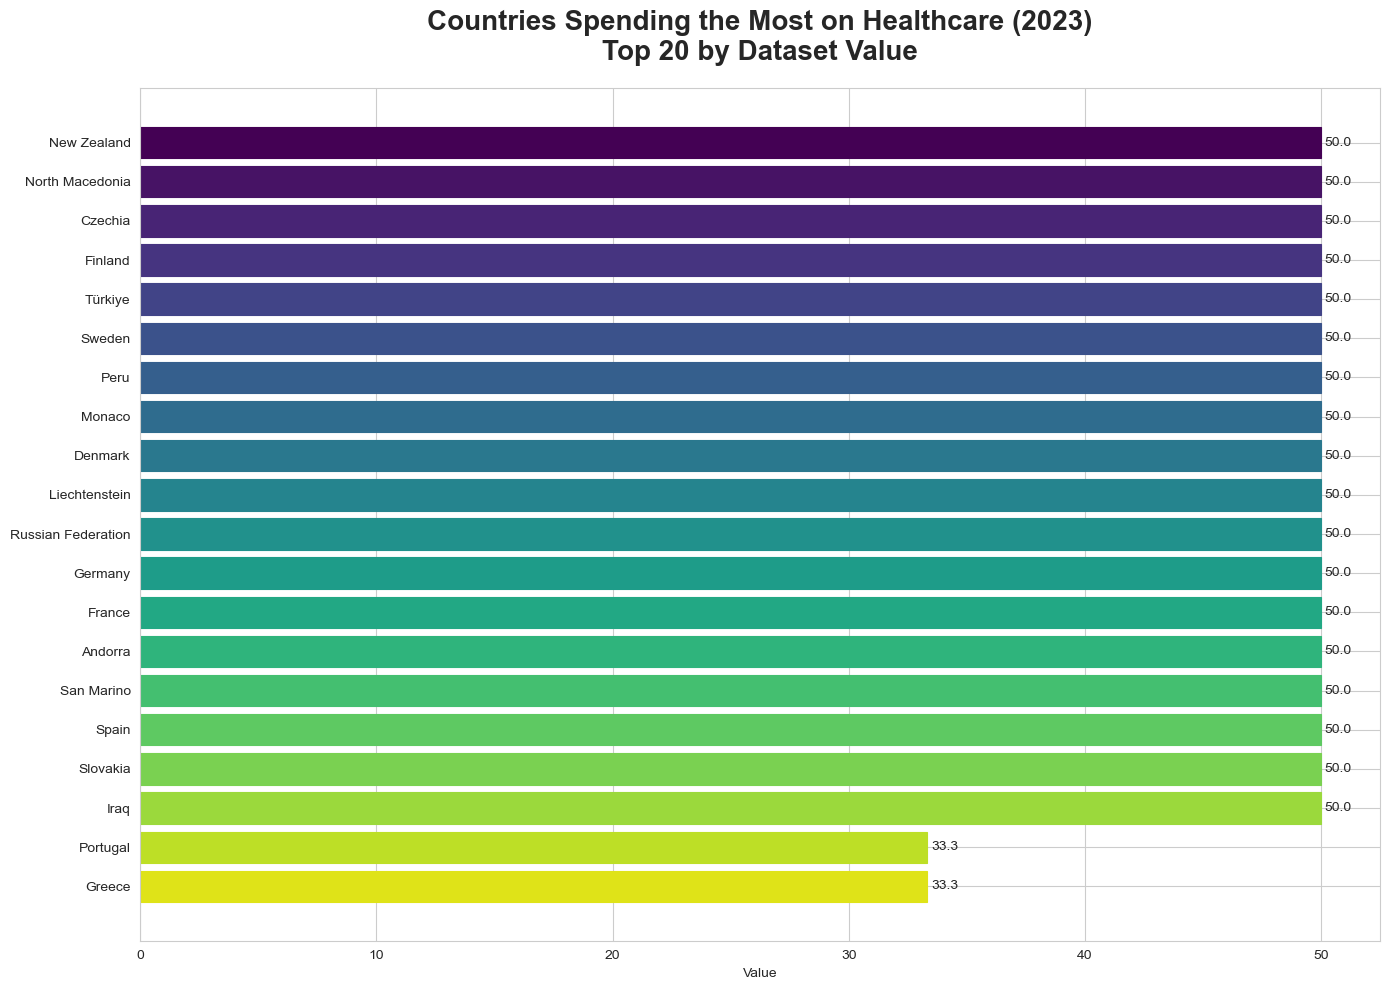

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -------------------------------
# Load data
# -------------------------------
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-04-21/health_spending.csv"
df = pd.read_csv(url)

# -------------------------------
# Pick latest year available
# -------------------------------
latest_year = df["year"].max()

# Use % of GDP expenditure type if available
gdp = df[
    (df["year"] == latest_year) &
    (df["unit"].str.contains("%", na=False))
].copy()

# remove missing
gdp = gdp.dropna(subset=["value"])

# top countries
top = gdp.groupby("country_name")["value"].mean().sort_values(ascending=False).head(20)

plot_df = top.reset_index()

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(14,10))
sns.set_style("whitegrid")

bars = plt.barh(
    plot_df["country_name"],
    plot_df["value"],
    edgecolor="black",
    linewidth=0.8
)

# color gradient
for i, bar in enumerate(bars):
    bar.set_color(plt.cm.viridis(i / len(bars)))

plt.gca().invert_yaxis()

# labels
for bar in bars:
    w = bar.get_width()
    plt.text(
        w + 0.15,
        bar.get_y() + bar.get_height()/2,
        f"{w:.1f}",
        va="center",
        fontsize=10
    )

plt.title(
    f"Countries Spending the Most on Healthcare ({latest_year})\nTop 20 by Dataset Value",
    fontsize=20,
    weight="bold",
    pad=20
)

plt.xlabel("Value")
plt.ylabel("")
plt.tight_layout()
plt.show()